In [1]:
import jax
import jax.numpy as jnp
import numpy as onp
import matplotlib.pyplot as plt

from utils import standardize_data
from score import kde_score_all, stein_score_all

This notebook reproduces Figures 3 and 4 from the paper.

## ANM

In [2]:
from mechanisms import flow_from_mechanism

class nn_conditioner_mechanism(flow_from_mechanism):

    def __init__(self, mech = "anm", **kwargs):
        super().__init__()
        assert mech in ["anm", "lsnm"], "mech must be either 'anm' or 'lsnm'."
        self.mech = mech
        if mech == "anm":
            n_out = 1
        elif mech == "lsnm":
            n_out = 2
        self.build_nn_params(n_out, **kwargs)

    def build_nn_params(self, n_out, layers = 3, hidden_size = 64, seed = 0, init_weight = 0.4):
        params = {"w1": jax.random.normal(shape=(1, hidden_size), key=jax.random.PRNGKey(seed))*init_weight,
                    "b1": jax.random.normal(shape=(hidden_size), key=jax.random.PRNGKey(seed + 1))*init_weight}
        for i in range(layers - 2):
            params[f"w{i+2}"] = jax.random.normal(shape=(hidden_size, hidden_size), key=jax.random.PRNGKey(seed))*init_weight
            params[f"b{i+2}"] = jax.random.normal(shape=(hidden_size), key=jax.random.PRNGKey(seed + 1))*init_weight
            seed = seed + 2
        params[f"w{layers}"] = jax.random.normal(shape=(hidden_size, n_out), key=jax.random.PRNGKey(seed))*init_weight
        params[f"b{layers}"] = jax.random.normal(shape=(n_out), key=jax.random.PRNGKey(seed + 1))*init_weight
        self.params = params
        self.layers = layers

    def nn_conditioner(self, x):
        x = jnp.array(x)
        if x.ndim == 1:
            x = x[:, None]
        h = x
        for i in range(self.layers-1):
            h = jnp.dot(h, self.params[f"w{i+1}"]) + self.params[f"b{i+1}"]
            h = jax.nn.tanh(h)
        out = jnp.dot(h, self.params[f"w{self.layers}"]) + self.params[f"b{self.layers}"]
        return out

    def forward(self, x, e):
        """
        compute y = f_{x}(e)
        """
        cond = self.nn_conditioner(x)
        if self.mech == "anm":
            return (e + cond.squeeze()).squeeze()
        elif self.mech == "lsnm":
            mu, sigma = cond[:, 0], jnp.exp(cond[:, 1])
            return (mu + (sigma+0.1) * e).squeeze()

    def inverse(self, x, y):
        """
        compute e = f^{-1}_x(y) 
        """
        cond = self.nn_conditioner(x)
        if self.mech == "anm":
            return (y - cond.squeeze()).squeeze()
        elif self.mech == "lsnm":
            mu, sigma = cond[:, 0], jnp.exp(cond[:, 1])
            return ((y - mu)/(sigma+0.1)).squeeze()

In [3]:
anm = nn_conditioner_mechanism(mech = "anm", layers = 5, hidden_size = 64, seed = 7)

x_data = jax.random.normal(shape = (2500,), key = jax.random.PRNGKey(1))
noise = jax.random.normal(shape = (2500,), key = jax.random.PRNGKey(2))
y_data = anm.forward(x_data, noise)

dat = jnp.concat((x_data[:, None], y_data[:, None]), axis = -1)

dat, dat_mean, dat_std = standardize_data(dat, return_statistics = True, trim_outliers = 0)
x_data, x_data_mean, x_data_std = dat[:,0], dat_mean[0], dat_std[0]
y_data, y_data_mean, y_data_std = dat[:,1], dat_mean[1], dat_std[1]

anm.set_normalization_statistics(x_data_mean, x_data_std, y_data_mean, y_data_std)

In [4]:
def gaussian_score_oracle(x, y, model):
    """
    Computes the ground truth sx, sxy given gaussian noise and mechanism "model". 
    """
    e = model.inverse_normalized(x, y)
    df = jax.vmap(jax.grad(model.inverse_normalized, (0, 1))) ## returns tuple (df-1/dx, df-1/dy)
    dfdy = jax.grad(model.inverse_normalized, 1)
    dfdxdy = jax.vmap(jax.grad(dfdy, (0,1))) ## returns tuple (d^2f-1/dxdy, d^2f-1/dy^2)

    dx_data, dy_data = df(x, y)
    dxdy_data, dydy_data = dfdxdy(x, y)

    sx = -x_data ## gaussian score 
    sxyx = -x_data + (-e)*(dx_data) + dxdy_data/dy_data
    sxyy = - e * dy_data + dydy_data/dy_data

        ## sx - dvdy - (sxyx + v * sxyy)) = ( -e * dx_data - v * e)

    sxy = jnp.stack((sxyx, sxyy), axis = -1)

    return sx, sxy

sx_true, sxy_true = gaussian_score_oracle(x_data, y_data, anm)
sx_kde, sy_kde, sxy_kde = kde_score_all(x_data, y_data, reg = 0.01)
sx_stein, sy_stein, sxy_stein = stein_score_all(x_data, y_data, reg = 0.1)

100%|██████████| 250/250 [00:03<00:00, 82.72it/s]


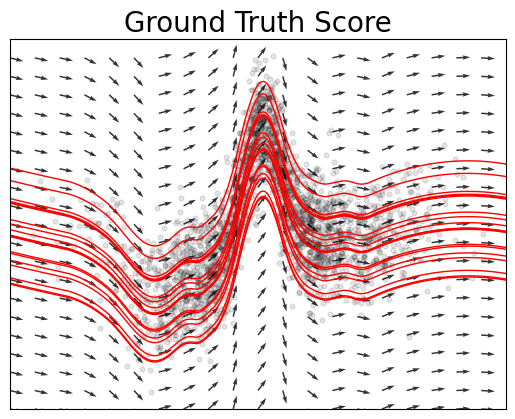

In [5]:
from models import anm_model
from training import fit_sm_bd 

model = anm_model(layers = 5, hidden_size = 64)
PARAMS_INIT = model.params_init(0, 0.4)


gof_fwd, _, _, _, params_fwd, _ = fit_sm_bd(PARAMS_INIT, model, x_data, y_data, sx_data = sx_true, 
                                            sy_data = jnp.ones_like(sx_true), sxy_data = sxy_true,
                                                        n_steps = 250)

from mechanisms import mechanism_from_flow

class trained_velocity_model(mechanism_from_flow):
    """
    Trained velocity model v(y, t; params)
    """
    def __init__(self, params):
        super().__init__()
        self.params = params

    def velocity(self, y, x):
        return model(y, x, self.params)

v_fwd = trained_velocity_model(params_fwd)

from plotting import plot_data, plot_flow, plot_velocity_grid

plot_data(x_data, y_data)

plot_flow(v_fwd.flow, x_init = jax.random.choice(key=jax.random.PRNGKey(0), a = x_data, shape = (20,)),
            y_init = jax.random.choice(key=jax.random.PRNGKey(0), a = y_data, shape = (20,)), 
            color = "r") 
plot_velocity_grid(v_fwd.velocity, n_pts = 20, color = "black")

plt.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)


plt.title("Ground Truth Score", fontsize = 20)

plt.show()


100%|██████████| 250/250 [00:03<00:00, 77.45it/s]


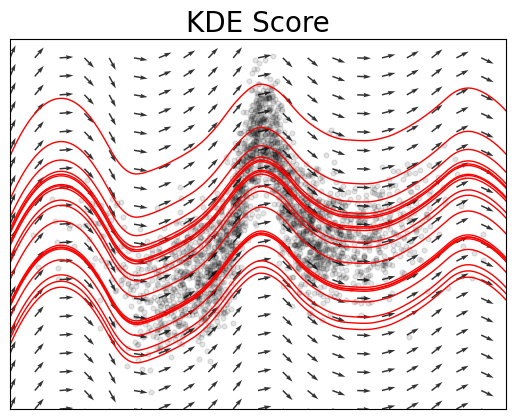

In [6]:
from models import anm_model
from training import fit_sm_bd 


gof_fwd, _, _, _, params_fwd, _ = fit_sm_bd(PARAMS_INIT, model, x_data, y_data, sx_data = sx_kde, 
                                            sy_data = jnp.ones_like(sx_kde), sxy_data = sxy_kde,
                                                        n_steps = 250)

from mechanisms import mechanism_from_flow

class trained_velocity_model(mechanism_from_flow):
    """
    Trained velocity model v(y, t; params)
    """
    def __init__(self, params):
        super().__init__()
        self.params = params

    def velocity(self, y, x):
        return model(y, x, self.params)

v_fwd = trained_velocity_model(params_fwd)

from plotting import plot_data, plot_flow, plot_velocity_grid

plot_data(x_data, y_data)

plot_flow(v_fwd.flow, x_init = jax.random.choice(key=jax.random.PRNGKey(0), a = x_data, shape = (20,)),
            y_init = jax.random.choice(key=jax.random.PRNGKey(0), a = y_data, shape = (20,)), 
            color = "r") 
plot_velocity_grid(v_fwd.velocity, n_pts = 20, color = "black")

plt.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)


plt.title("KDE Score", fontsize = 20)

plt.show()


100%|██████████| 250/250 [00:03<00:00, 77.81it/s]


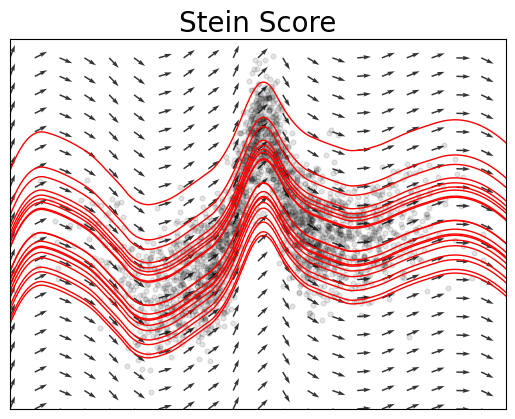

In [7]:
from models import anm_model
from training import fit_sm_bd 


gof_fwd, _, _, _, params_fwd, _ = fit_sm_bd(PARAMS_INIT, model, x_data, y_data, sx_data = sx_stein, 
                                            sy_data = jnp.ones_like(sx_stein), sxy_data = sxy_stein,
                                                        n_steps = 250)

from mechanisms import mechanism_from_flow

class trained_velocity_model(mechanism_from_flow):
    """
    Trained velocity model v(y, t; params)
    """
    def __init__(self, params):
        super().__init__()
        self.params = params

    def velocity(self, y, x):
        return model(y, x, self.params)

v_fwd = trained_velocity_model(params_fwd)

from plotting import plot_data, plot_flow, plot_velocity_grid

plot_data(x_data, y_data)

plot_flow(v_fwd.flow, x_init = jax.random.choice(key=jax.random.PRNGKey(0), a = x_data, shape = (20,)),
            y_init = jax.random.choice(key=jax.random.PRNGKey(0), a = y_data, shape = (20,)), 
            color = "r") 
plot_velocity_grid(v_fwd.velocity, n_pts = 20, color = "black")

plt.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)


plt.title("Stein Score", fontsize = 20)

plt.show()


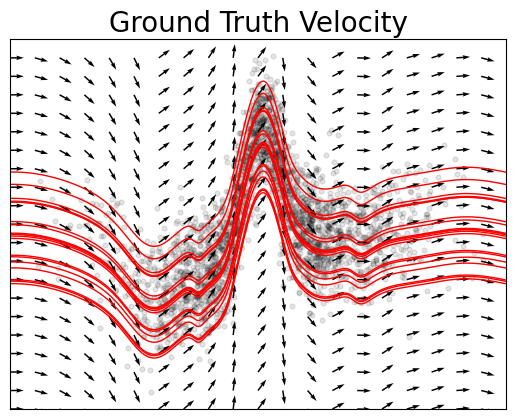

In [8]:

plot_data(x_data, y_data)
plot_flow(anm.flow_normalized, x_init = jax.random.choice(key=jax.random.PRNGKey(0), a = x_data, shape = (20,)),
            y_init = jax.random.choice(key=jax.random.PRNGKey(0), a = y_data, shape = (20,)), 
            color = "r") 
plot_velocity_grid(jax.vmap(anm.velocity, in_axes = (0,0)), n_pts = 20, color = "black", alpha = 1)

plt.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)

plt.title("Ground Truth Velocity", fontsize = 20)

plt.show()


## LSNM

In [9]:
lsnm = nn_conditioner_mechanism(mech = "lsnm", layers = 4, hidden_size = 64, seed = 7)

x_data = jax.random.normal(shape = (2500,), key = jax.random.PRNGKey(1))
noise = jax.random.normal(shape = (2500,), key = jax.random.PRNGKey(2))
y_data = lsnm.forward(x_data, noise)

dat = jnp.concat((x_data[:, None], y_data[:, None]), axis = -1)

dat, dat_mean, dat_std = standardize_data(dat, return_statistics = True, trim_outliers = 0)
x_data, x_data_mean, x_data_std = dat[:,0], dat_mean[0], dat_std[0]
y_data, y_data_mean, y_data_std = dat[:,1], dat_mean[1], dat_std[1]

lsnm.set_normalization_statistics(x_data_mean, x_data_std, y_data_mean, y_data_std)

sx_true, sxy_true = gaussian_score_oracle(x_data, y_data, lsnm)
sx_kde, sy_kde, sxy_kde = kde_score_all(x_data, y_data, reg = 0.01)
sx_stein, sy_stein, sxy_stein = stein_score_all(x_data, y_data, reg = 0.1)

100%|██████████| 250/250 [00:02<00:00, 101.83it/s]


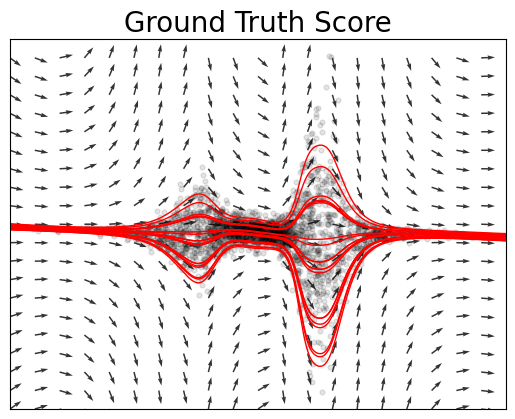

In [10]:
from models import lsnm_model

model = lsnm_model(layers = 2, hidden_size = 64)
PARAMS_INIT = model.params_init(0, 0.2)


gof_fwd, _, _, _, params_fwd, _ = fit_sm_bd(PARAMS_INIT, model, x_data, y_data, sx_data = sx_true, 
                                            sy_data = jnp.ones_like(sx_true), sxy_data = sxy_true,
                                                        n_steps = 250, lam_complexity = 0, lam_l2 = 0)

from mechanisms import mechanism_from_flow

class trained_velocity_model(mechanism_from_flow):
    """
    Trained velocity model v(y, t; params)
    """
    def __init__(self, params):
        super().__init__()
        self.params = params

    def velocity(self, y, x):
        return model(y, x, self.params)

v_fwd = trained_velocity_model(params_fwd)

from plotting import plot_data, plot_flow, plot_velocity_grid

plot_data(x_data, y_data)

plot_flow(v_fwd.flow, x_init = jax.random.choice(key=jax.random.PRNGKey(0), a = x_data, shape = (20,)),
            y_init = jax.random.choice(key=jax.random.PRNGKey(0), a = y_data, shape = (20,)), 
            color = "r") 
plot_velocity_grid(v_fwd.velocity, n_pts = 20, color = "black")

plt.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)


plt.title("Ground Truth Score", fontsize = 20)

plt.show()


100%|██████████| 250/250 [00:02<00:00, 97.51it/s] 


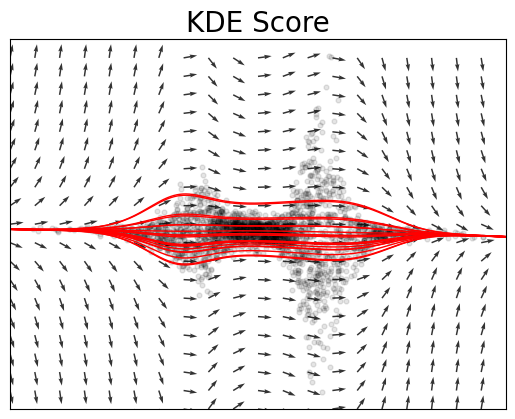

In [11]:
gof_fwd, _, _, _, params_fwd, _ = fit_sm_bd(PARAMS_INIT, model, x_data, y_data, sx_data = sx_kde, 
                                            sy_data = jnp.ones_like(sx_kde), sxy_data = sxy_kde,
                                                        n_steps = 250, lam_complexity = 0, lam_l2 = 0)

from mechanisms import mechanism_from_flow

class trained_velocity_model(mechanism_from_flow):
    """
    Trained velocity model v(y, t; params)
    """
    def __init__(self, params):
        super().__init__()
        self.params = params

    def velocity(self, y, x):
        return model(y, x, self.params)

v_fwd = trained_velocity_model(params_fwd)

plot_data(x_data, y_data)

plot_flow(v_fwd.flow, x_init = jax.random.choice(key=jax.random.PRNGKey(0), a = x_data, shape = (20,)),
            y_init = jax.random.choice(key=jax.random.PRNGKey(0), a = y_data, shape = (20,)), 
            color = "r") 
plot_velocity_grid(v_fwd.velocity, n_pts = 20, color = "black")

plt.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)


plt.title("KDE Score", fontsize = 20)

plt.show()


100%|██████████| 250/250 [00:02<00:00, 100.39it/s]


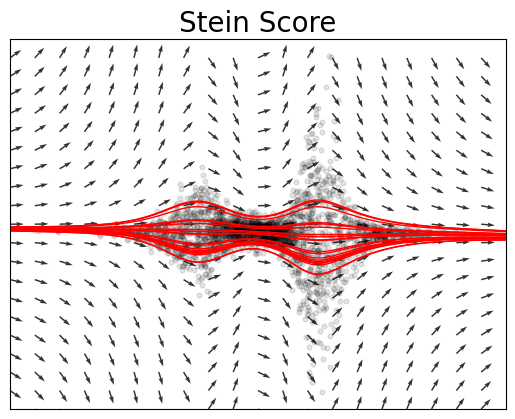

In [12]:
gof_fwd, _, _, _, params_fwd, _ = fit_sm_bd(PARAMS_INIT, model, x_data, y_data, sx_data = sx_stein, 
                                            sy_data = jnp.ones_like(sx_stein), sxy_data = sxy_stein,
                                            lam_complexity = 0, lam_l2 = 0, n_steps = 250)

from mechanisms import mechanism_from_flow

class trained_velocity_model(mechanism_from_flow):
    """
    Trained velocity model v(y, t; params)
    """
    def __init__(self, params):
        super().__init__()
        self.params = params

    def velocity(self, y, x):
        return model(y, x, self.params)

v_fwd = trained_velocity_model(params_fwd)

from plotting import plot_data, plot_flow, plot_velocity_grid

plot_data(x_data, y_data)

plot_flow(v_fwd.flow, x_init = jax.random.choice(key=jax.random.PRNGKey(0), a = x_data, shape = (20,)),
            y_init = jax.random.choice(key=jax.random.PRNGKey(0), a = y_data, shape = (20,)), 
            color = "r") 
plot_velocity_grid(v_fwd.velocity, n_pts = 20, color = "black")

plt.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)


plt.title("Stein Score", fontsize = 20)

plt.show()


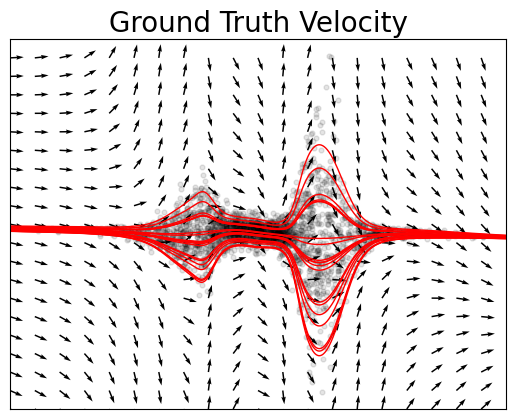

In [13]:

plot_data(x_data, y_data)
plot_flow(lsnm.flow_normalized, x_init = jax.random.choice(key=jax.random.PRNGKey(0), a = x_data, shape = (20,)),
            y_init = jax.random.choice(key=jax.random.PRNGKey(0), a = y_data, shape = (20,)), 
            color = "r") 
plot_velocity_grid(jax.vmap(lsnm.velocity, in_axes = (0,0)), n_pts = 20, color = "black", alpha = 1)

plt.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)

plt.title("Ground Truth Velocity", fontsize = 20)

plt.show()
